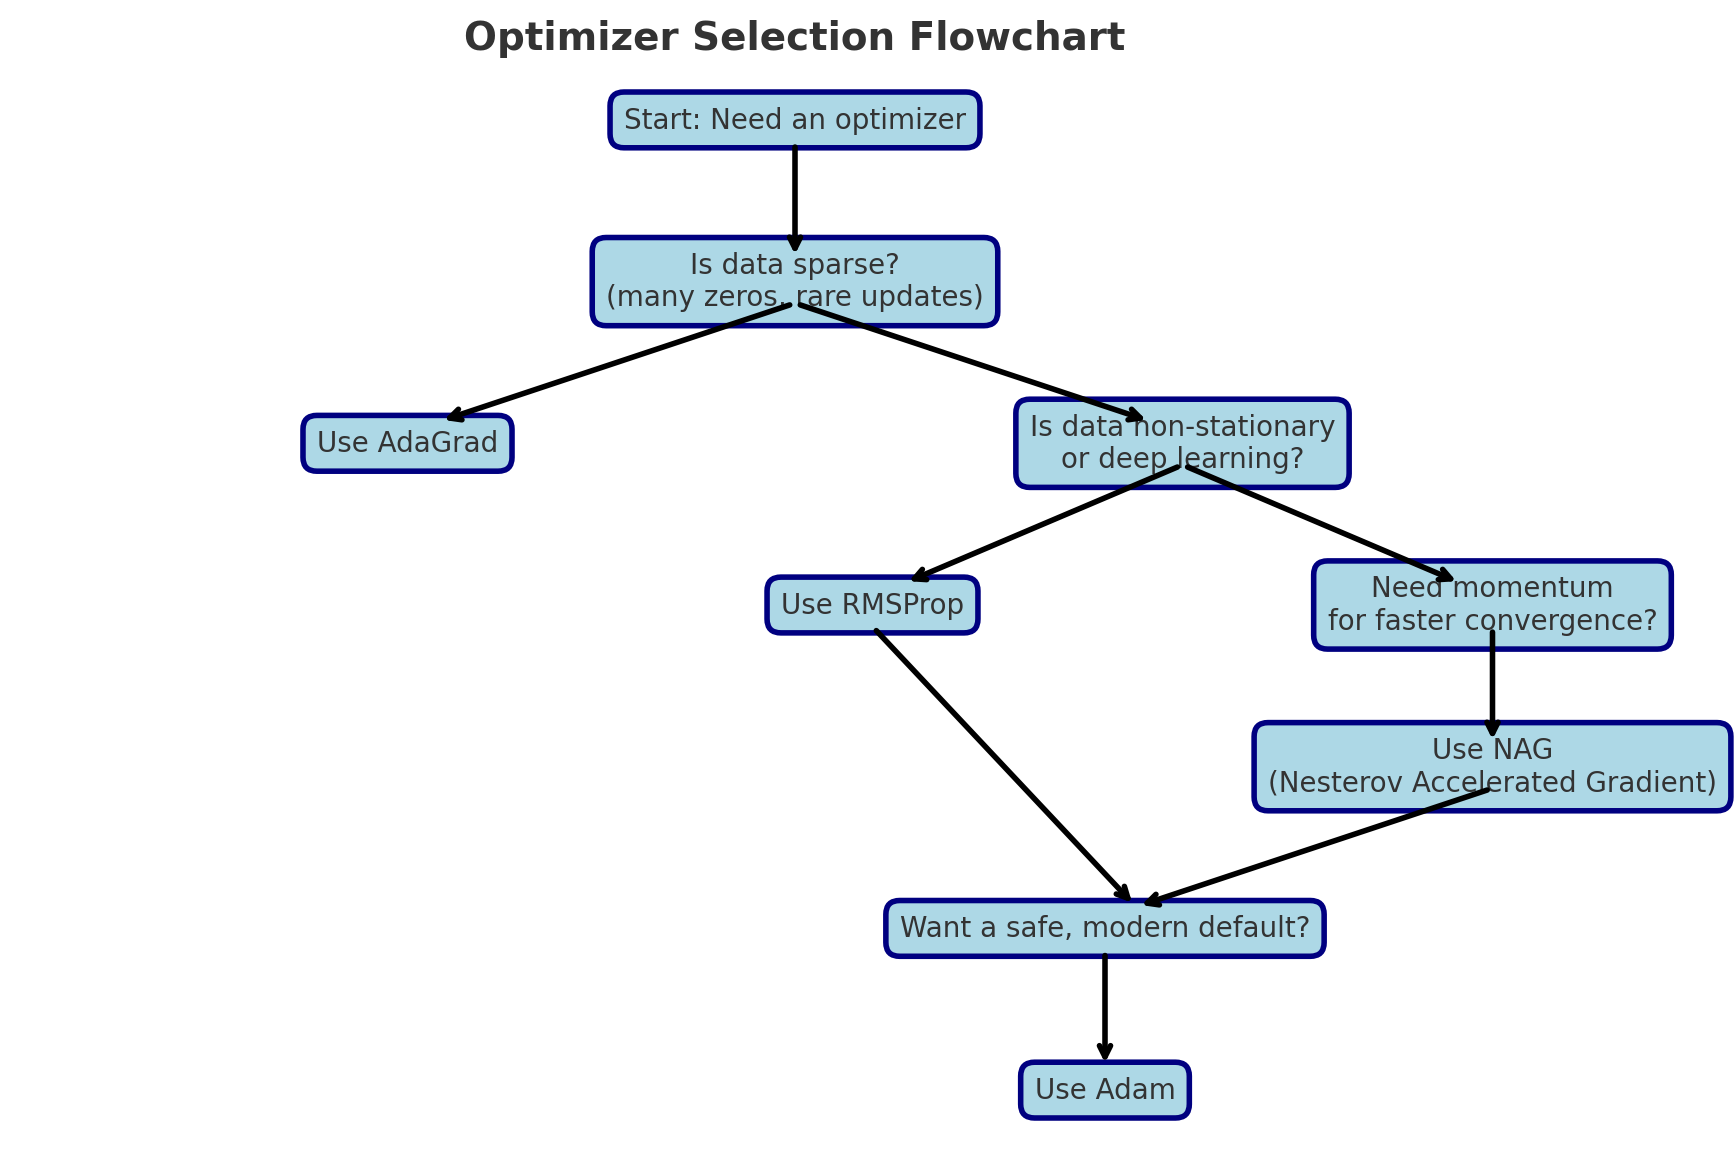

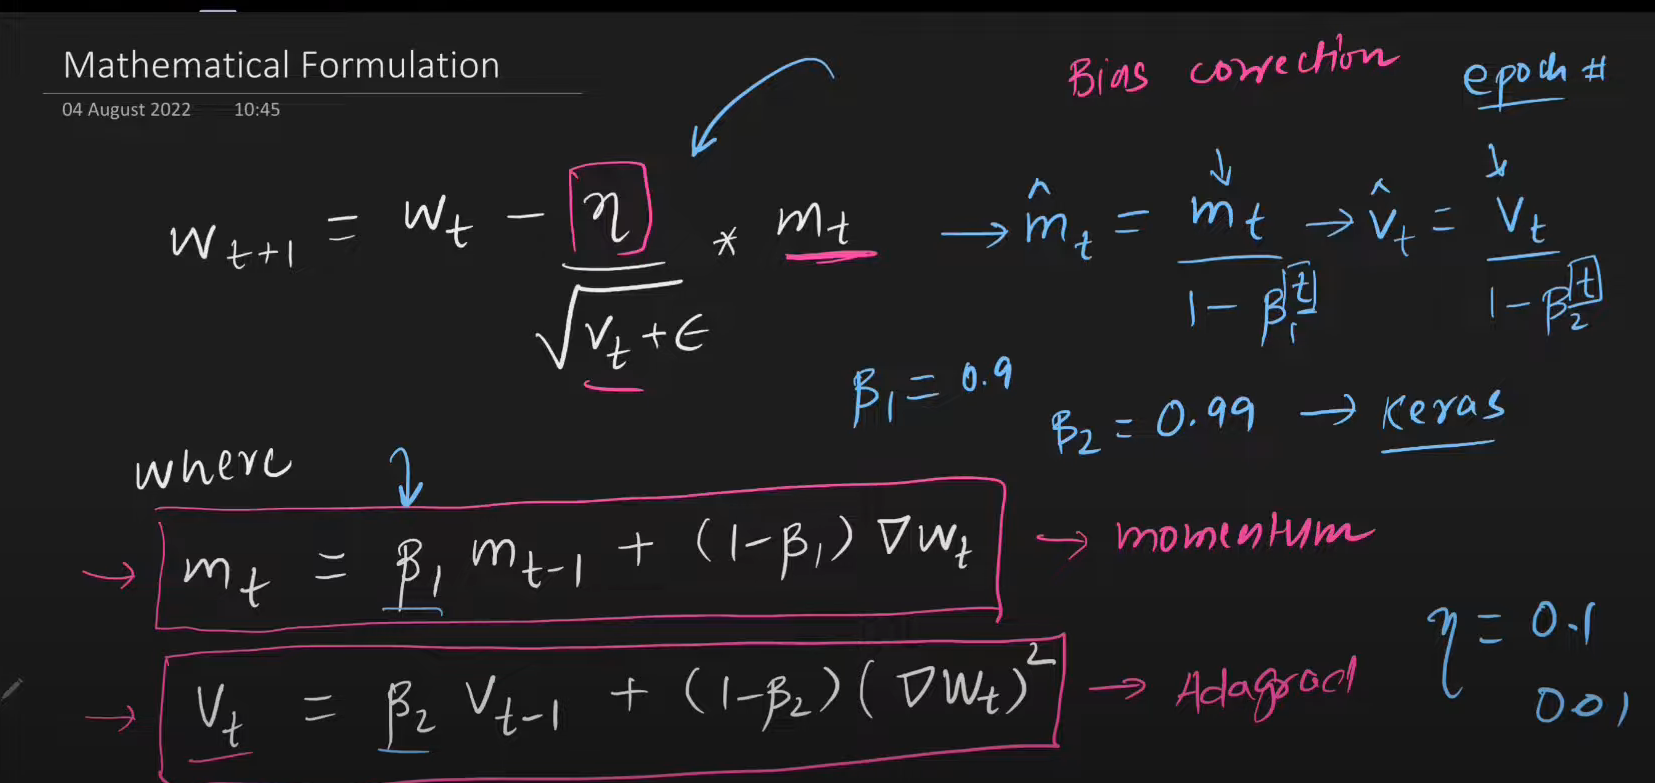


---

## **1. The Goal**

We want to update weights $w_t$ to $w_{t+1}$ in a way that learns quickly but doesn’t jump around too much.
The main update rule in the picture is:

$$
w_{t+1} = w_t - \frac{\eta \cdot m_t}{\sqrt{v_t} + \epsilon}
$$

* $\eta$ → learning rate (step size)
* $m_t$ → running average of gradients (like momentum)
* $v_t$ → running average of squared gradients (like Adagrad)
* $\epsilon$ → small number to avoid division by zero

---

## **2. Momentum Part ($m_t$)**

This smooths out the gradient so we don’t react too strongly to sudden changes:

$$
m_t = \beta_1 m_{t-1} + (1 - \beta_1) \nabla w_t
$$

* $\beta_1$ controls how much we remember from the past
* In Keras defaults: $\beta_1 = 0.9$
* This is like keeping a rolling average of recent steps.

---

## **3. Adaptive Part ($v_t$)**

This keeps track of the size of gradients:

$$
v_t = \beta_2 v_{t-1} + (1 - \beta_2)(\nabla w_t)^2
$$

* $\beta_2$ controls how much we remember old squared gradients
* In Keras defaults: $\beta_2 = 0.99$
* This helps make learning rate smaller for parameters that change a lot.

---

## **4. Bias Correction**

At the start of training, $m_t$ and $v_t$ are too small (biased).
To fix this:

$$
\hat{m}_t = \frac{m_t}{1 - \beta_1^t}
$$

$$
\hat{v}_t = \frac{v_t}{1 - \beta_2^t}
$$

These “hat” values are the corrected versions.

---

## **5. How Adam Combines Everything**

Adam uses:

* **Momentum** → $m_t$ for smooth direction
* **Adaptive learning rates** → $v_t$ for adjusting step size
* Bias correction to make early steps fair

So the final weight update is:

$$
w_{t+1} = w_t - \frac{\eta \cdot \hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
$$

---

💡 **Easy analogy**:
Imagine walking toward a target in a windy field:

* Momentum helps you keep moving steadily in the right direction without getting blown off by sudden gusts.
* Adaptive learning rate slows you down when steps are too big and speeds you up when they’re too small.
* Bias correction makes sure your first steps aren’t awkwardly tiny.

---




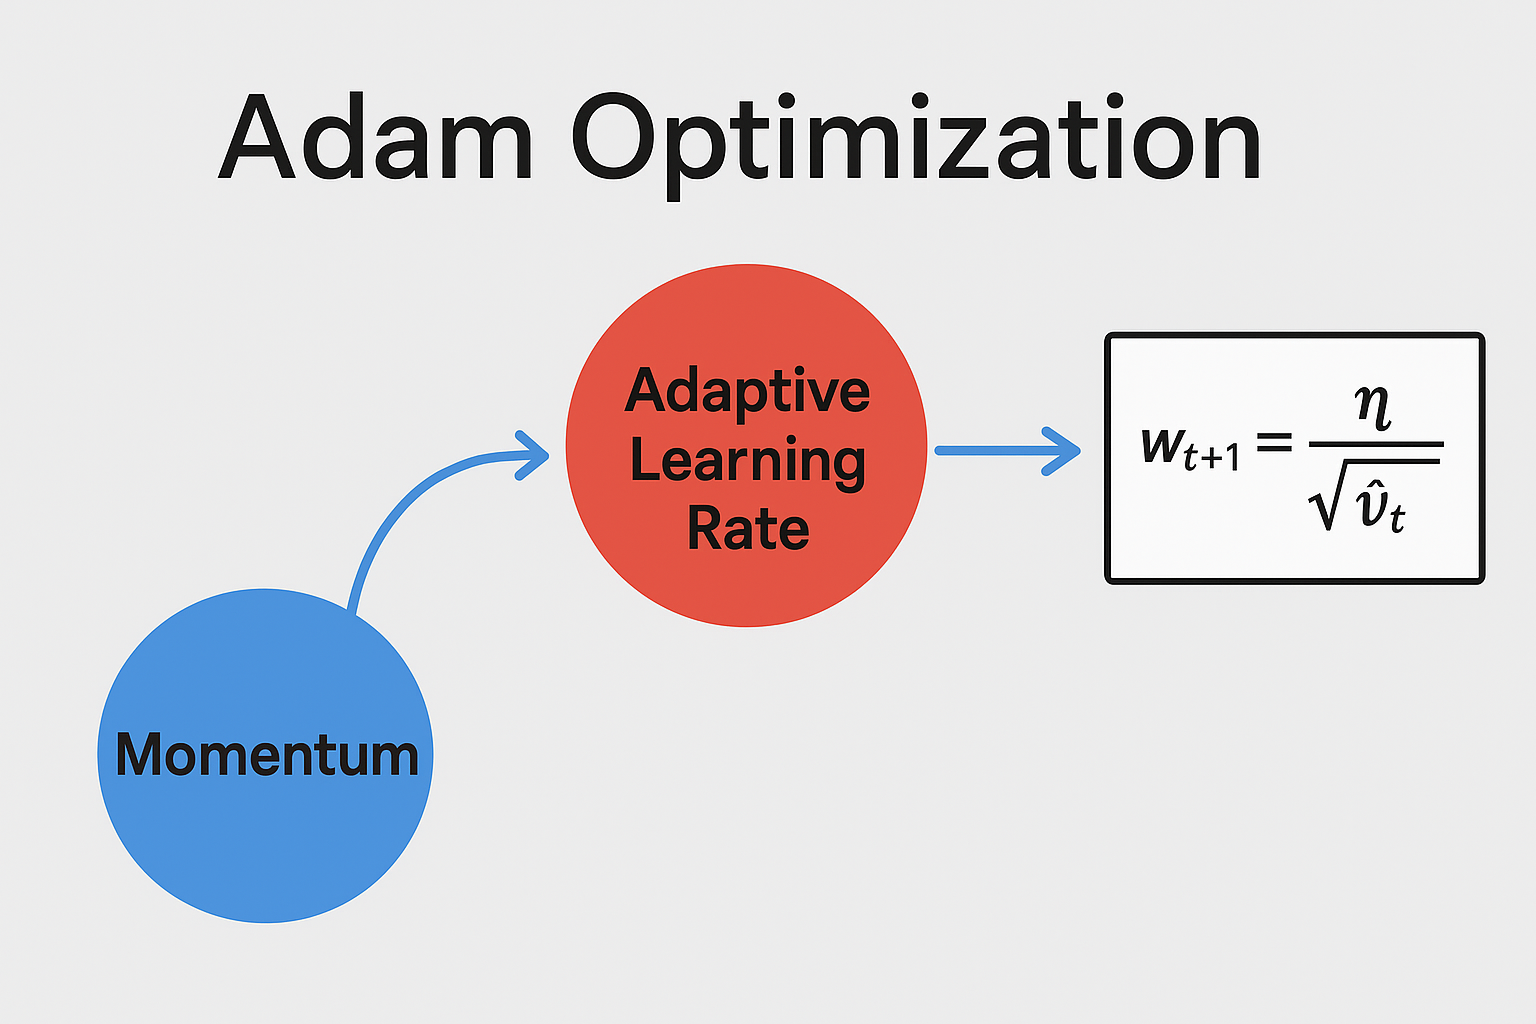


---

## 🎬 **The Adam Adventure**

**Main Characters**:

1. **Momentum Mike** → smooth talker, remembers past moves so we don’t get too jumpy.
2. **Adaptive Amy** → careful observer, adjusts step size so we don’t trip or overshoot.
3. **Bias Buster Ben** → fixes early mistakes when data is scarce.

---

### **Scene 1 – Momentum Mike**

Mike runs toward the goal but doesn’t change direction too sharply.
Formula:

$$
m_t = \beta_1 m_{t-1} + (1 - \beta_1) \nabla w_t
$$

*(Keeps a rolling average of where the slope is pointing.)*

---

### **Scene 2 – Adaptive Amy**

Amy looks at how bumpy the path is.
If the ground is very uneven (big gradients), she tells Mike to take smaller steps.
Formula:

$$
v_t = \beta_2 v_{t-1} + (1 - \beta_2) (\nabla w_t)^2
$$

*(Keeps a rolling average of squared slopes.)*

---

### **Scene 3 – Bias Buster Ben**

At the start of training, Mike’s and Amy’s notes are too short and incomplete.
Ben rescales their notes so they make sense.
Formulas:

$$
\hat{m}_t = \frac{m_t}{1 - \beta_1^t}
$$

$$
\hat{v}_t = \frac{v_t}{1 - \beta_2^t}
$$

---

### **Scene 4 – The Final Step**

All three work together:

$$
w_{t+1} = w_t - \frac{\eta \cdot \hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
$$

Mike sets the direction, Amy sets the pace, Ben makes sure they start off fair.

---

## 🎯 **Memory Trick** – *MAB* Rule

* **M** → Momentum Mike (smooth direction)
* **A** → Adaptive Amy (adjust speed)
* **B** → Bias Buster Ben (correct start)

*"In Adam, MAB works together to reach the goal!"*

---





---

## ✅ **When to Use Adam**

* **Most deep learning tasks** → Works well for CNNs, RNNs, transformers, etc.
* **When gradients are noisy** → Handles unstable updates better than vanilla SGD.
* **When you have sparse data or features** → Adapts learning rate per parameter.
* **When you want quick convergence** → Often faster to a good solution than plain SGD.
* **Default choice for beginners** → Keras and PyTorch set it as default for a reason.

---

## ⚠️ **Cons of Adam**

1. **Can overfit** → Because it adapts too well to training data, sometimes generalization is worse than SGD with momentum.
2. **May stop improving early** → Sometimes plateaus at a suboptimal solution (SGD can eventually find better minima).
3. **Extra memory cost** → Needs to store $m_t$ and $v_t$ for each parameter, doubling memory usage compared to SGD.
4. **Learning rate sensitivity** → Even though it’s adaptive, too high or too low η still causes trouble.
5. **Not always best for fine-tuning** → In transfer learning, SGD with momentum sometimes gives better final accuracy.

---

💡 **Rule of thumb**:

* **Start with Adam** → If it’s good enough, keep it.
* If validation accuracy is lower than expected or you want better generalization → Try **SGD with momentum**.

---



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

# Simple feedforward model
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(x)

# Create model
model = MyModel()

# Loss function
criterion = nn.CrossEntropyLoss()

# Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Dummy data loader (replace with real one)
x = torch.randn(64, 28*28)   # batch of 64, flattened 28x28 images
y = torch.randint(0, 10, (64,))  # batch of labels

# Training loop
for epoch in range(5):
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, y)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")


Epoch 1, Loss: 2.3378
Epoch 2, Loss: 2.0237
Epoch 3, Loss: 1.7536
Epoch 4, Loss: 1.5194
Epoch 5, Loss: 1.3154
